# Make figure 10

files needed:

Model output: not publicly available
Mhw statistics: 

`mhwMetrics.nc`
Mhw ocetrac output: 

`ocetrac-v9-blobs-tos-t1-r1-msq0-01860315-01891214-region.nc`


In [1]:
import xarray as xr
import dask

import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 20})

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import cmocean.cm as cm

In [3]:
# hfdrake_path = "/pub/hfdrake/datasets/CM4_MHW_blobs/"
model_data_path = "/dfs9/hfdrake_hpc/datasets/CM4_MHW_blobs/data_daily/"
path = "/pub/mariant3/WarmWaterMassesv1/"

In [ ]:
ds = xr.open_mfdataset(f"{model_data_path}/01860101.ocean_daily.*.nc", chunks={"time":1})
metrics = xr.open_dataset(f"{path}data/mhwMetrics.nc")

labels = (xr.open_dataset(
    f"{mt_path}ocetracv9/ocetrac-v9-blobs-tos-t1-r1-msq0-01860315-01891214-region.nc").sel(
    time=slice(f"0186", f"0189"))).blobs.rename('event_mask')

xh_min = labels.xh.min()
xh_max = labels.xh.max()
yh_min = labels.yh.min()
yh_max = labels.yh.max()

static2 = (
    xr.open_dataset(
        "/dfs9/hfdrake_hpc/datasets/CM4_MHW_blobs/data/WMT_monthly/ocean_month_rho2.static.nc"
    )
    .sel(xh=slice(xh_min,xh_max),
         yh=slice(yh_min,yh_max))
)

# tos = xr.open_dataset(f"/dfs9/hfdrake_hpc/datasets/CM4_MHW_blobs/data/ocean_daily_cmip.01860101-01901231.tos.nc", chunks={'time':100})

In [15]:
h = ds.thkcello.where(ds.thetao > 29).sum("zl")
h = h.sel(time=slice(labels.time.min(), labels.time.max()))

# labels = labels.sel(time=h.time)

In [18]:
regions = {
    "gom":     [-84,   27],
    "baja":    [-107,  19],
    "pacific": [-93.5, 15],
}


def plot_wwm_map(
    ax,
    t,
    title="",
    event_id=None,
    star_xy=None,
    marker_style="*",   # NEW
    markersize="30",
    h=h,
    labels=labels,
    static2=static2,
    custom_colors_all=custom_colors_all,
    vmin=0,
    vmax=20,
):
    h_t = h.isel(time=t)
    labels_t = labels.isel(time=t)

    bg_cmap = cm.deep.copy()
    bg_cmap.set_bad((0.7, 0.7, 0.7))

    static2.deptho.plot(
        ax=ax,
        x="xh",
        y="yh",
        cmap=bg_cmap,
        add_colorbar=False,
    )

    static2.deptho.fillna(0).plot.contour(
        ax=ax,
        x="xh",
        y="yh",
        levels=[5],
        colors="k",
        linewidths=1,
    )

    vals = np.unique(labels_t.values)
    vals = vals[~np.isnan(vals)]
    blob_ids = vals.astype(int)

    for blob in blob_ids:
        if blob == 0:
            continue

        color = custom_colors_all.get(blob, "#BDBDBD")

        cmap_blob = mcolors.LinearSegmentedColormap.from_list(
            f"blob_{blob}",
            ["white", color],
        )

        h_t.where(labels_t == blob).plot.contourf(
            ax=ax,
            x="xh",
            y="yh",
            cmap=cmap_blob,
            vmin=vmin,
            vmax=vmax,
            levels=12,
            add_colorbar=False,
        )

        (labels_t == blob).plot.contour(
            ax=ax,
            x="xh",
            y="yh",
            levels=[0.95],
            colors=[color],
            linewidths=1.4,
            add_colorbar=False,
        )

        (labels_t == blob).plot.contour(
            ax=ax,
            x="xh",
            y="yh",
            levels=[0.95],
            colors="k",
            linewidths=0.9,
            alpha=0.5,
            add_colorbar=False,
        )

    if event_id is not None and star_xy is not None:
        star_color = custom_colors_all.get(event_id, "#BDBDBD")

        ax.plot(
            star_xy[0],
            star_xy[1],
            marker=marker_style,
            color="k",
            markeredgecolor="k",
            linestyle="None",
            markersize=markersize,
            markeredgewidth=2,
            zorder=30,
        )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    ti = h.time.isel(time=t)
    datestr = f"{ti.dt.year.values}-{ti.dt.month.values:02d}-{ti.dt.day.values:02d}"
    
    if title == "":
        title = datestr
    else:
        title = f"{title} on {datestr} at max area"
    
    ax.text(
        0.008,
        1.08,
        title,
        transform=ax.transAxes,
        va="top",
        ha="left",
    )

    return ax

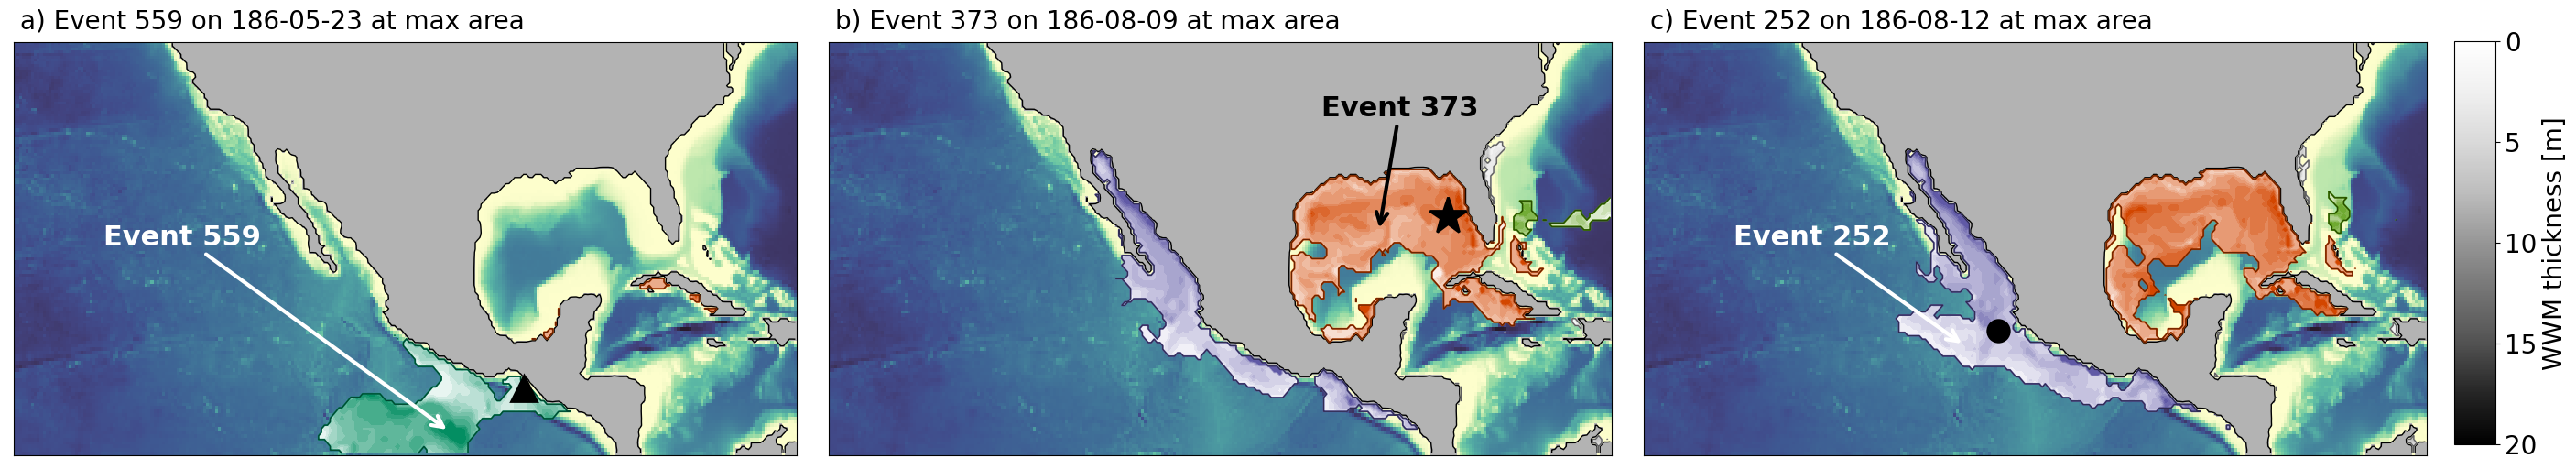

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(30, 5.5))
plot_wwm_map(
    axs[0],
    t=69,
    title="a) Event 559",
    event_id=559,
    star_xy=regions["pacific"],
    marker_style="^",
    markersize=20,
)

axs[0].annotate(
    "Event 559",
    color='w',
    fontweight='bold',
    xy=(-100, 12),
    xytext=(-130, 25),
    fontsize=22,
    arrowprops=dict(
        arrowstyle="->",
        lw=3,
        color="w",
    ),
)

plot_wwm_map(
    axs[1],
    t=147,
    title="b) Event 373",
    event_id=373,
    star_xy=regions["gom"],
    marker_style="*",
    markersize=30,
)

axs[1].annotate(
    "Event 373",
    color='k',
    fontweight='bold',
    xy=(-90, 26),
    xytext=(-95, 34),
    fontsize=22,
    arrowprops=dict(
        arrowstyle="->",
        lw=3,
        color="k",
    ),
)

plot_wwm_map(
    axs[2],
    t=150,
    title="c) Event 252",
    event_id=252,
    star_xy=regions["baja"],
    marker_style="o",
    markersize=17,
)

axs[2].annotate(
    "Event 252",
    color='w',
    fontweight='bold',
    xy=(-110, 18),
    xytext=(-130, 25),
    fontsize=22,
    arrowprops=dict(
        arrowstyle="->",
        lw=3,
        color="w",
    ),
)

# dedicated colorbar axis, so no subplot shrinks
norm = mpl.colors.Normalize(vmin=0, vmax=20)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="Greys")
sm.set_array([])

cax = fig.add_axes([0.9, 0.085, 0.015, 0.8])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("WWM thickness [m]")
cbar.ax.invert_yaxis()

plt.tight_layout(rect=[0, 0, 0.90, 1])

# plt.savefig("../figures/WWM_thickness.png", dpi=400, bbox_inches="tight")

plt.show()